In [1]:
from pathlib import Path

import pandas as pd

project_root = Path.cwd().resolve().parent
csv_path = project_root / "data" / "sp500_cluster_results.csv"

if not csv_path.exists():
    raise FileNotFoundError(f"Could not find cluster results at {csv_path}")

data = pd.read_csv(csv_path)
print(data.head())
print()
print(f"Loaded {data.shape[0]} rows and {data.shape[1]} columns from {csv_path}")

  ticker        security                  sector  \
0    IQV           IQVIA             Health Care   
1   DECK  Deckers Brands  Consumer Discretionary   
2   TSLA     Tesla, Inc.  Consumer Discretionary   
3     DG  Dollar General        Consumer Staples   
4    DHI    D. R. Horton  Consumer Discretionary   

                          sub_industry  return_3m  return_1y  volatility  \
0       Life Sciences Tools & Services  -0.287549   0.139345    0.364595   
1                             Footwear   0.068343   0.011013    0.493975   
2             Automobile Manufacturers  -0.114526   0.541113    0.625719   
3  Consumer Staples Merchandise Retail  -0.178168   0.394942    0.420711   
4                         Homebuilding  -0.097559   0.198486    0.360923   

   max_drawdown  corr_with_spy  median_dollar_volume_m  cluster  \
0     -0.455377       0.483664              275.685094        0   
1     -0.643494       0.461523              297.459405        0   
2     -0.537657       0.60733

## First Check: Cluster Quality

Before doing PCA, inspect the distribution of `distance_to_centroid` to see whether clusters are compact or whether a few stocks are far from their assigned cluster.

Distance-to-centroid summary
count    501.000000
mean       1.240730
std        0.599749
min        0.301264
50%        1.126920
90%        1.828400
95%        2.130435
99%        3.539119
max        6.608819
Name: distance_to_centroid, dtype: float64

Stocks farthest from their assigned cluster centroid


,ticker,cluster,sector,distance_to_centroid
249,LITE,2,Information Technology,6.608819
479,SMCI,4,Information Technology,4.991173
495,SATS,4,Communication Services,4.447983
100,APP,0,Information Technology,3.568526
500,COHR,4,Information Technology,3.543537
251,STX,2,Information Technology,3.539119
25,COIN,0,Financials,3.345632
473,GLW,4,Information Technology,3.322493
35,TTD,0,Communication Services,3.164527
471,MU,4,Information Technology,3.160997


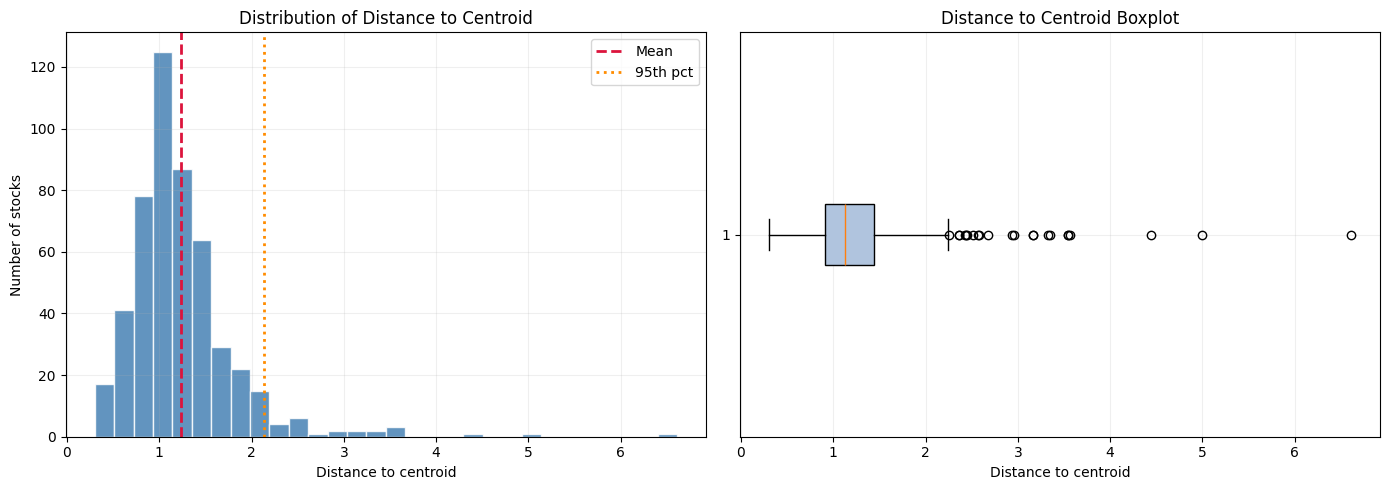

In [2]:
import matplotlib.pyplot as plt

if "distance_to_centroid" not in data.columns:
    raise KeyError(
        "Expected a 'distance_to_centroid' column in the clustering results. "
        f"Available columns: {list(data.columns)}"
    )

distance = data["distance_to_centroid"].dropna()
summary = distance.describe(percentiles=[0.5, 0.9, 0.95, 0.99])

print("Distance-to-centroid summary")
print(summary)
print()

label_columns = [
    column
    for column in ["ticker", "cluster", "sector", "distance_to_centroid"]
    if column in data.columns
]

most_distant = data.loc[distance.nlargest(10).index, label_columns].sort_values(
    "distance_to_centroid", ascending=False
)
print("Stocks farthest from their assigned cluster centroid")
display(most_distant)

fig, (ax_hist, ax_box) = plt.subplots(1, 2, figsize=(14, 5))

ax_hist.hist(distance, bins=30, color="steelblue", edgecolor="white", alpha=0.85)
ax_hist.axvline(distance.mean(), color="crimson", linestyle="--", linewidth=2, label="Mean")
ax_hist.axvline(distance.quantile(0.95), color="darkorange", linestyle=":", linewidth=2, label="95th pct")
ax_hist.set_title("Distribution of Distance to Centroid")
ax_hist.set_xlabel("Distance to centroid")
ax_hist.set_ylabel("Number of stocks")
ax_hist.legend()
ax_hist.grid(alpha=0.2)

ax_box.boxplot(distance, vert=False, patch_artist=True, boxprops={"facecolor": "lightsteelblue"})
ax_box.set_title("Distance to Centroid Boxplot")
ax_box.set_xlabel("Distance to centroid")
ax_box.grid(alpha=0.2)

fig.tight_layout()
plt.show()

In [3]:
outlier_threshold = distance.quantile(0.95)
top_n = 10

outliers = data.loc[data["distance_to_centroid"] >= outlier_threshold].copy()
outliers = outliers.sort_values("distance_to_centroid", ascending=False)

top_outliers = outliers.head(top_n)

print(f"Outlier threshold (95th percentile): {outlier_threshold:.3f}")
print(f"Stocks above threshold: {outliers.shape[0]}")
print()
print(f"Top {min(top_n, outliers.shape[0])} outliers by distance_to_centroid")

display_columns = [
    column
    for column in [
        "ticker",
        "cluster",
        "sector",
        "distance_to_centroid",
        "return_3m",
        "return_1y",
        "volatility",
        "max_drawdown",
        "correlation_with_index",
    ]
    if column in top_outliers.columns
]

display(top_outliers[display_columns].reset_index(drop=True))

Outlier threshold (95th percentile): 2.130
Stocks above threshold: 26

Top 10 outliers by distance_to_centroid


,ticker,cluster,sector,distance_to_centroid,return_3m,return_1y,volatility,max_drawdown
0,LITE,2,Information Technology,6.608819,1.687474,16.021008,0.745062,-0.506276
1,SMCI,4,Information Technology,4.991173,0.004598,-0.142512,0.980446,-0.812411
2,SATS,4,Communication Services,4.447983,0.010756,4.826737,0.885699,-0.487992
3,APP,0,Information Technology,3.568526,-0.245516,0.974372,0.823451,-0.569972
4,COHR,4,Information Technology,3.543537,0.781544,4.842537,0.702718,-0.548473
5,STX,2,Information Technology,3.539119,0.705962,6.412472,0.518073,-0.400006
6,COIN,0,Financials,3.345632,-0.218987,0.131668,0.788438,-0.663895
7,GLW,4,Information Technology,3.322493,0.844474,3.051511,0.407329,-0.275677
8,TTD,0,Communication Services,3.164527,-0.387019,-0.532072,0.624507,-0.855996
9,MU,4,Information Technology,3.160997,0.372198,5.453457,0.614153,-0.576290


## Cluster Summary

Aggregate the main clustering features by cluster so each group has a compact behavioral profile.

In [4]:
df = data.copy()

required_columns = [
    "cluster",
    "return_3m",
    "return_1y",
    "volatility",
    "max_drawdown",
    "ticker",
]

correlation_column = None
for candidate in ["corr_with_spy", "correlation_with_index"]:
    if candidate in df.columns:
        correlation_column = candidate
        break

if correlation_column is None:
    raise KeyError(
        "Expected either 'corr_with_spy' or 'correlation_with_index' in the data. "
        f"Available columns: {list(df.columns)}"
    )

missing_columns = [
    column for column in required_columns if column not in df.columns
]
if missing_columns:
    raise KeyError(
        f"Missing required columns for cluster summary: {missing_columns}"
    )

cluster_summary = (
    df.groupby("cluster", dropna=False)
    .agg(
        {
            "return_3m": "mean",
            "return_1y": "mean",
            "volatility": "mean",
            "max_drawdown": "mean",
            correlation_column: "mean",
            "ticker": "count",
        }
    )
    .rename(columns={"ticker": "count", correlation_column: "corr_with_spy"})
    .sort_index()
    .round(4)
)

cluster_summary

,return_3m,return_1y,volatility,max_drawdown,corr_with_spy,count
cluster,,,,,,
0,-0.1526,0.0207,0.4199,-0.5233,0.4162,104
1,0.0405,0.1124,0.2313,-0.2280,0.1905,144
2,1.0384,9.7597,0.6004,-0.4645,0.5378,4
3,0.0136,0.3417,0.2959,-0.3026,0.5300,219
4,0.3654,2.0295,0.5512,-0.5196,0.5368,30
